In [3]:
import math
import os
import cv2
import hydra
import tonic
import torch
from tonic.transforms import Optional, ToFrame
from datasets.utils.pad_tensors import PadTensors
from datasets.utils.diskcache import DiskCachedDataset
import pytorch_lightning as pl
from sklearn.model_selection import train_test_split
import numpy as np
from pandas import DataFrame, read_csv

/raid/home/michael.siegl/projects/SE-adlif/.venv/lib/python3.11/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


## Data Preparation
We first need to preprocess the raw data found in the data path into a **Tonic** dataset. 

In [10]:
sensor_size = (320, 320, 2)

data_path = "/raid/home/michael.siegl/datasets/welding-data/csv"
file_list = ["120cmpm.csv", "60cmpm.csv", "30cmpm.csv"]

event_data = []

for file_name in file_list:
    csv_path = os.path.join(data_path, file_name)
    df = read_csv(csv_path, header=None, names=["x", "y", "p", "t"])
    event_data.append(df.to_numpy())

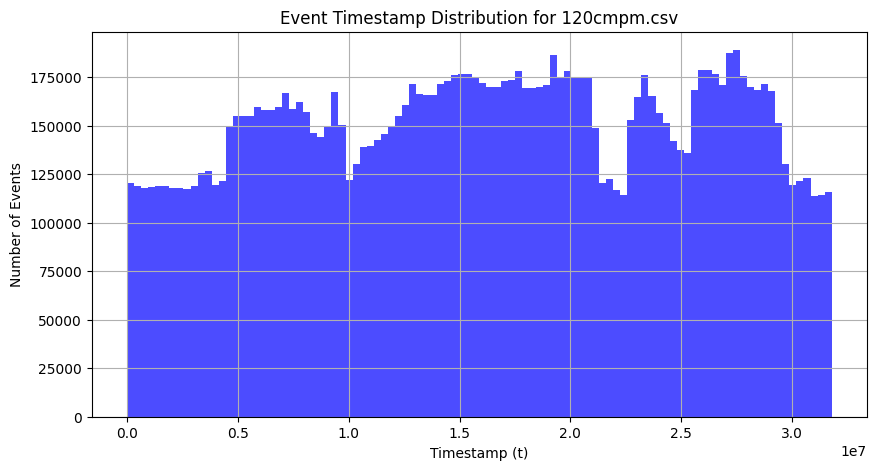

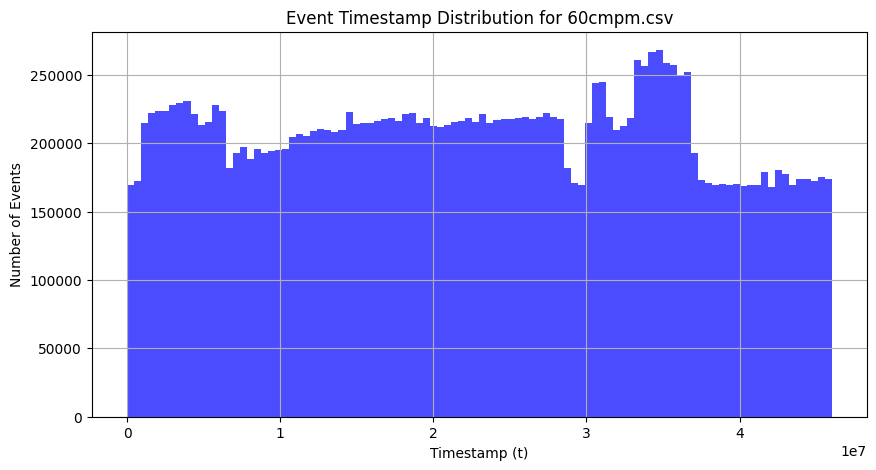

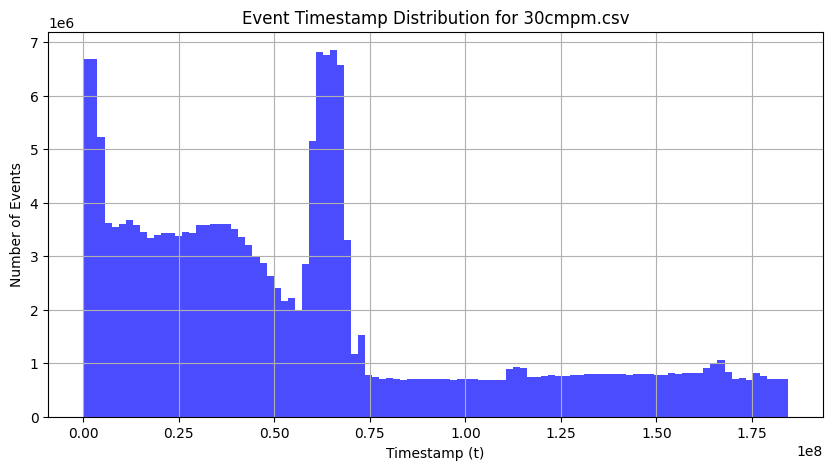

In [48]:
# great now we need to plot a histogram of the event data to see how the events are distributed over time, plot for all 3 files, add in 0.1 scale x axis to see the distribution better, and add in a grid for better visibility
# okay no, again, the 3 videos are on different timescales, so we need to plot them separately, but in the same figure, so we can compare them better, only video 3 is on e8, the others are on e7 but from like 1-3
import matplotlib.pyplot as plt
for i, data in enumerate(event_data):
    plt.figure(figsize=(10, 5))
    plt.hist(data[:, 3], bins=100, color='blue', alpha=0.7)
    plt.title(f'Event Timestamp Distribution for {file_list[i]}')
    plt.xlabel('Timestamp (t)')
    plt.ylabel('Number of Events')
    plt.grid()
    plt.show()

In [62]:
video2 = event_data[1][np.logical_and(event_data[1][:, 3] > 0.65e7, event_data[1][:, 3] < 2.85e7)] 

In [24]:
# cut off everything past 0.75e8 for event[2] to remove the long stretch of nothing happening
# video3 = event_data[2][event_data[2][:, 3] < 0.75e8]
# print(f"Video 3 shape after cutoff: {video3.shape}")
# shit actually i just watched the video, it needs to be done the other way around, the activity in the beginning is too high because there is illumination 
# in the video after 1 minute 57 seconds the important part begins and it ends at 2 minutes 40 seconds -> which needs to be translated due to window size
video3 = event_data[2][np.logical_and(event_data[2][:, 3] > 1.27e8, event_data[2][:, 3] < 1.6e8)] 
print(f"Video 3 shape after cutoff: {video3.shape}")

Video 3 shape after cutoff: (14259222, 4)


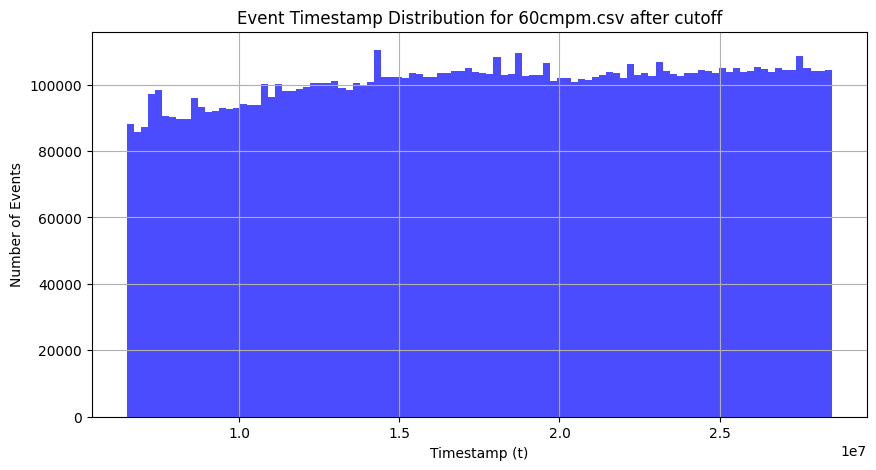

In [64]:
# plot only video3
plt.figure(figsize=(10, 5))
plt.hist(video2[:, 3], bins=100, color='blue', alpha=0.7)
plt.title(f'Event Timestamp Distribution for {file_list[1]} after cutoff')
plt.xlabel('Timestamp (t)')
plt.ylabel('Number of Events')
plt.grid()
plt.show()

In [26]:
# quick code snippet to transform and then save video3 as a .avi file
transformed_video3 = np.zeros((video3.shape[0],), dtype=[("x", "<i8"), ("y", "<i8"), ("p", "<i8"), ("t", "<i8")])
transformed_video3["x"] = video3[:, 0]
transformed_video3["y"] = video3[:, 1]
transformed_video3["p"] = video3[:, 2]
transformed_video3["t"] = video3[:, 3]
print(f"Transformed video3 shape: {transformed_video3.shape}")

_event_to_tensor = ToFrame(sensor_size=sensor_size, time_window=50000)
video3_frames = _event_to_tensor(transformed_video3)
print(f"Frames shape: {video3_frames.shape}")

video_path = "welding_video3.avi"
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(video_path, fourcc, 20.0, (sensor_size[0], sensor_size[1]))       
for i in range(video3_frames.shape[0]):
    # Sum positive and negative event channels → shape (320, 320)
    frame = video3_frames[i].sum(axis=0).astype(np.float32)

    frame = np.log1p(frame)  # log(1 + x) handles zeros safely
    frame_min, frame_max = frame.min(), frame.max()
    if frame_max > frame_min:
        frame = (frame - frame_min) / (frame_max - frame_min) * 255.0
    frame = frame.astype(np.uint8)

    # Convert single-channel to 3-channel BGR (required by VideoWriter)
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

    out.write(frame_bgr)
out.release()   

Transformed video3 shape: (14259222,)
Frames shape: (659, 2, 320, 320)


In [ ]:
# just overwrite the old csv file with the stuff from video3 ,but no header and no index like in the og file    
output_csv_path = os.path.join(data_path, "30cmpm.csv")
np.savetxt(output_csv_path, video3, delimiter=",", fmt="%d")

## Analysis
great so for 
### video 1 120cmpm 
we know that the welding process starts at ~1.0 and ends with that drop in activity at roughly ~2.0

### video 2 60cmpm
between 0.65e7 and 2.85e7

### video 3 30 cmpm
for video 3 its from 1:57 to 2:40, so from 1.27e0 to 1.60e8

In [27]:
# transforming the events in the numpy array into tonic compatible events, with the format (x, y, p, t) and the dtype for each entry "<i8"
transformed_events = np.zeros((event_data[1].shape[0],), dtype=[("x", "<i8"), ("y", "<i8"), ("p", "<i8"), ("t", "<i8")])
transformed_events["x"] = event_data[1][:, 0]
transformed_events["y"] = event_data[1][:, 1]
transformed_events["p"] = event_data[1][:, 2]
transformed_events["t"] = event_data[1][:, 3]
print(f"Transformed events shape: {transformed_events}")

Transformed events shape: [(128,  53, 0,        2) (294, 175, 0,        4) (100, 215, 0,        8)
 ... ( 38, 308, 0, 46019997) ( 65,  30, 0, 46019999)
 (206, 238, 0, 46019999)]


In [28]:
# great now we're gonna use the to frame transformer to convert the raw data into frames and visualize them
_event_to_tensor = ToFrame(sensor_size=sensor_size, time_window=50000)
frames = _event_to_tensor(transformed_events)
print(f"Frames shape: {frames.shape}")

Frames shape: (920, 2, 320, 320)


In [29]:
video_path = "welding_video.avi"
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(video_path, fourcc, 20.0, (sensor_size[0], sensor_size[1]))

for i in range(frames.shape[0]):
    # Sum positive and negative event channels → shape (320, 320)
    frame = frames[i].sum(axis=0).astype(np.float32)

    frame = np.log1p(frame)  # log(1 + x) handles zeros safely
    frame_min, frame_max = frame.min(), frame.max()
    if frame_max > frame_min:
        frame = (frame - frame_min) / (frame_max - frame_min) * 255.0
    frame = frame.astype(np.uint8)

    # Convert single-channel to 3-channel BGR (required by VideoWriter)
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

    out.write(frame_bgr)

out.release()
print(f"Video saved to {video_path}")

Video saved to welding_video.avi
